# Analysis of GitHub Trending Languages (Short-Term Trends)

### Course:
Big Data Engineering, FH Technikum Wien, Summer Semester 2025

### Team Members:
- Manpreet Misson  
- Timothy Gregorian  
- Omar Sidi Mammar

### Notebook Description  
This notebook presents a streaming pipeline that analyzes short-term technology trends on GitHub using **Apache Kafka** and **Apache Spark Structured Streaming**.

A cleaned JSON dataset of GitHub trending repositories is streamed via Kafka at short intervals. Spark processes the data in real time, aggregates programming language usage, and identifies the **top trending languages**.

The analysis covers a **brief timeframe in 2025** (May 14 – June 18), offering insights into current open-source activity.

The pipeline showcases a **scalable, event-driven architecture** for real-time tech trend analytics.

### Goals of this Notebook
- Stream a cleaned dataset of GitHub repositories via **Kafka**.
- Process the stream using **Spark Structured Streaming**.
- Count repositories per programming language and year.
- Visualize the most popular languages in **2025**.


### Import Dependencies for Analysis
This block loads all the necessary libraries used for Kafka message production, structured streaming with PySpark, logging, data transformation, and visualization.

In [1]:
from kafka import KafkaProducer
import json, time, os
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col, desc, to_timestamp, current_timestamp, expr
from pyspark.sql.functions import to_timestamp, to_date, year, col, min as min_, max as max_
from pyspark.sql.types import StructType, StringType
import logging
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger("KafkaProducer")

### Initialize Kafka Producer
This block creates a Kafka producer instance that connects to the specified Kafka broker. It serializes Python dictionaries into JSON format and encodes them as UTF-8 bytes before sending.


In [2]:
producer = KafkaProducer(
    bootstrap_servers="172.29.16.101:9092",
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

2025-06-23 10:29:25,922 - INFO - <BrokerConnection node_id=bootstrap-0 host=172.29.16.101:9092 <connecting> [IPv4 ('172.29.16.101', 9092)]>: connecting to 172.29.16.101:9092 [('172.29.16.101', 9092) IPv4]
2025-06-23 10:29:25,925 - INFO - Probing node bootstrap-0 broker version
2025-06-23 10:29:25,927 - INFO - <BrokerConnection node_id=bootstrap-0 host=172.29.16.101:9092 <connecting> [IPv4 ('172.29.16.101', 9092)]>: Connection complete.
2025-06-23 10:29:26,035 - INFO - Broker version identified as 2.5.0
2025-06-23 10:29:26,037 - INFO - Set configuration api_version=(2, 5, 0) to skip auto check_version requests on startup


### Send Scraped JSON Data to Kafka Topic
This block reads cleaned GitHub trending data from a local JSON file and sends each valid entry to the Kafka topic `"github-trending-all"`. Only entries with a valid `"language"` field are sent. Each message is serialized and pushed using the Kafka producer with a short delay to simulate streaming.


In [3]:
topic = "github-trending-all-v3"
json_path = "./ScrapedData/ScrapData_All_Cleaned.json"

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)
    for entry in data:
        if "language" in entry and entry["language"] != "N/A":
            producer.send(topic, entry)
            logger.info(f"Sent: {entry['name']}")
            time.sleep(0.01) 

producer.flush()
producer.close()
logger.info("Kafka Producer finished sending.")

2025-06-23 10:29:26,066 - INFO - <BrokerConnection node_id=1 host=172.29.16.101:9092 <connecting> [IPv4 ('172.29.16.101', 9092)]>: connecting to 172.29.16.101:9092 [('172.29.16.101', 9092) IPv4]
2025-06-23 10:29:26,066 - INFO - Sent: microsoft/BitNet
2025-06-23 10:29:26,068 - INFO - <BrokerConnection node_id=1 host=172.29.16.101:9092 <connecting> [IPv4 ('172.29.16.101', 9092)]>: Connection complete.
2025-06-23 10:29:26,071 - INFO - <BrokerConnection node_id=bootstrap-0 host=172.29.16.101:9092 <connected> [IPv4 ('172.29.16.101', 9092)]>: Closing connection. 
2025-06-23 10:29:26,080 - INFO - Sent: xaoyaoo/PyWxDump
2025-06-23 10:29:26,092 - INFO - Sent: ahmedkhaleel2004/gitdiagram
2025-06-23 10:29:26,104 - INFO - Sent: i-am-alice/3rd-devs
2025-06-23 10:29:26,117 - INFO - Sent: xming521/WeClone
2025-06-23 10:29:26,132 - INFO - Sent: openai/simple-evals
2025-06-23 10:29:26,145 - INFO - Sent: alibaba/spring-ai-alibaba
2025-06-23 10:29:26,161 - INFO - Sent: airweave-ai/airweave
2025-06-23 10:

### Initialize Spark Session
This block creates a SparkSession configured to connect to a remote Spark cluster. The application is named `"GitHubTrendingAllTimev1"` and uses the specified Spark master node to distribute tasks.


In [4]:
spark = SparkSession.builder \
    .appName("GitHubTrendingAllTime") \
    .master("local[*]") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/23 10:29:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
25/06/23 10:29:30 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.


### Read Streaming Data from Kafka
This block initializes a streaming DataFrame by connecting to a Kafka topic named `"github-trending-all"`. It reads all available data from the earliest offset and listens for new incoming records continuously.


In [5]:
df_kafka = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "172.29.16.101:9092") \
    .option("subscribe", "github-trending-all-v3") \
    .option("startingOffsets", "earliest") \
    .load()

25/06/23 10:29:31 WARN FileSystem: Cannot load filesystem: java.util.ServiceConfigurationError: org.apache.hadoop.fs.FileSystem: com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem Unable to get public no-arg constructor
25/06/23 10:29:31 WARN FileSystem: java.lang.NoClassDefFoundError: com/google/api/client/http/HttpRequestInitializer
25/06/23 10:29:31 WARN FileSystem: java.lang.ClassNotFoundException: com.google.api.client.http.HttpRequestInitializer


### Define Data Schema  
This block defines the schema for the incoming JSON data, specifying the expected fields such as repository name, description, programming language, star count, URL, and the timestamp when the data was scraped. This schema ensures that the data is correctly parsed and typed when loaded into Spark.


In [6]:
schema = StructType() \
    .add("name", StringType()) \
    .add("description", StringType()) \
    .add("language", StringType()) \
    .add("stars", StringType()) \
    .add("url", StringType()) \
    .add("scraped_at", StringType())

### Parse and Filter Kafka Data  
This code reads the raw Kafka messages as strings, parses them into structured data using the predefined schema, and selects all fields from the parsed JSON. It then filters out entries where the programming language is missing or marked as "N/A" to ensure only valid language data is processed.


In [7]:
df = df_kafka.selectExpr("CAST(value AS STRING)") \
    .select(from_json(col("value"), schema).alias("data")) \
    .select("data.*") \
    .filter(col("language").isNotNull() & (col("language") != "N/A"))

### Extract and Transform Timestamp Columns  
Here, the code converts the `scraped_at` string field into a timestamp and a date format, creating new columns `scraped_at_ts` and `scraped_date`. It also extracts the year from the timestamp into a separate `year` column. These transformations facilitate time-based grouping and analysis.


In [8]:
df_with_time = df.withColumn("scraped_at_ts", to_timestamp("scraped_at")) \
                 .withColumn("scraped_date", to_date("scraped_at")) \
                 .withColumn("year", year(col("scraped_at_ts")))


### Start Streaming Query to Memory  
This block initiates a streaming query that writes the processed data (`df_with_time`) into an in-memory table named `df_with_time_mem`. The query appends new data every 5 seconds. The `time.sleep(15)` call allows the streaming query to run briefly and accumulate data in memory before further processing.


In [9]:
query = df_with_time.writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("df_with_time_mem") \
    .trigger(processingTime="5 seconds") \
    .start()

time.sleep(15) 

25/06/23 10:29:32 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-51be8f24-bb86-4039-a706-e7a0c267cc74. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/06/23 10:29:32 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
25/06/23 10:29:33 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


### Retrieve Data from Memory and Determine Date Range  
This code queries the in-memory streaming table `df_with_time_mem` to create a static DataFrame `df_static`. It then computes the minimum and maximum scraped dates within the dataset to dynamically determine the analysis time range, which is printed for reference.


In [10]:
df_static = spark.sql("SELECT * FROM df_with_time_mem")

min_date, max_date = df_static.select(min_("scraped_date"), max_("scraped_date")).first()
print(f"Timeframe: {min_date} bis {max_date}")


Timeframe: 2025-05-14 bis 2025-06-19


### Aggregate Repository Counts by Year and Language  
This segment groups the static DataFrame by `year` and `language`, counting the number of repositories for each combination. The count column is renamed to `repo_count` for clarity. The resulting DataFrame is registered as a temporary SQL view `lang_stats_by_year` to enable querying and further analysis using Spark SQL.


In [11]:
top_languages_by_year = df_static.groupBy("year", "language") \
    .count() \
    .withColumnRenamed("count", "repo_count")

top_languages_by_year.createOrReplaceTempView("lang_stats_by_year")


In [12]:
df_result = spark.sql("SELECT * FROM lang_stats_by_year ORDER BY year, repo_count DESC")
df_pd = df_result.toPandas()

### Visualize Language Trends and Totals
Generates a stacked bar chart of repository counts per programming language across years, using a pivoted DataFrame with color mapping and labeled axes. Also prints the total number of repositories and a sorted summary of counts per language.

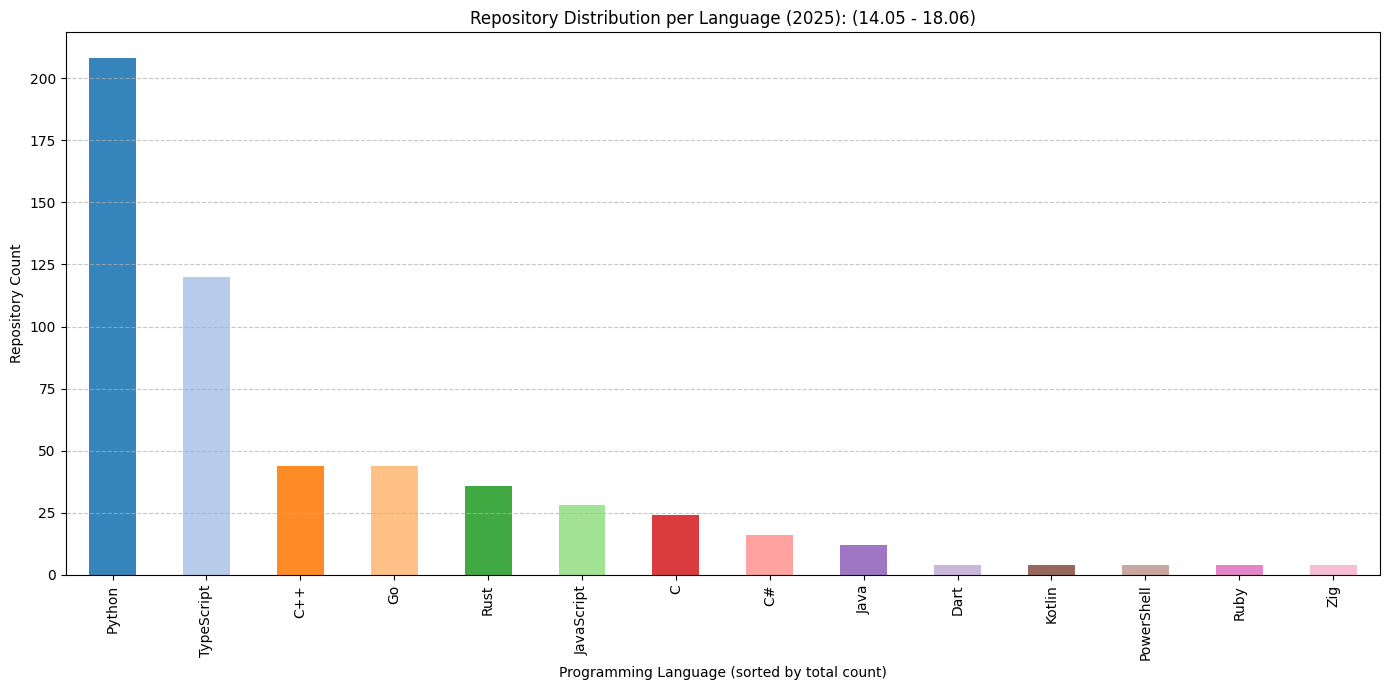

Total Repositories: 552

Python: 208 repositories
TypeScript: 120 repositories
C++: 44 repositories
Go: 44 repositories
Rust: 36 repositories
JavaScript: 28 repositories
C: 24 repositories
C#: 16 repositories
Java: 12 repositories
Kotlin: 4 repositories
Ruby: 4 repositories
Zig: 4 repositories
PowerShell: 4 repositories
Dart: 4 repositories


In [13]:
bar_data = df_pd[df_pd["year"] == 2025].groupby("language")["repo_count"].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))

cmap = plt.get_cmap("tab20")
colors = [cmap(i % 20) for i in range(len(bar_data))]

bar_data.plot(
    kind="bar",
    color=colors,
    alpha=0.9,
)

plt.title(f"Repository Distribution per Language (2025): (14.05 - 18.06)")
plt.xlabel("Programming Language (sorted by total count)")
plt.ylabel("Repository Count")
plt.xticks(rotation=90)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

total_repos = df_pd["repo_count"].sum()
print(f"Total Repositories: {total_repos}\n")
for lang, count in zip(df_pd["language"], df_pd["repo_count"]):
    print(f"{lang}: {count} repositories")


In [14]:
query.stop()
logger.info("Spark stream stopped.")

2025-06-23 10:29:50,108 - INFO - Spark stream stopped.


In [15]:
spark.stop()
logger.info("Spark session stopped.")

2025-06-23 10:29:50,442 - INFO - Spark session stopped.
